<a href="https://colab.research.google.com/github/ansuman1981/SEA-Inequality-Research/blob/main/SEA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import the packages
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as mp

#load th dataset
df = pd.read_excel("/content/SEA_Master_Data_FINAL.xlsx")
print(df.shape)
print(df.head(10))
print(df.dtypes)

(144, 5)
  Code    Country  Year  KOFGI  Gini
0  IDN  Indonesia  2000   60.0  30.3
1  IDN  Indonesia  2001   60.2  31.2
2  IDN  Indonesia  2002   57.1  30.2
3  IDN  Indonesia  2003   57.5  29.3
4  IDN  Indonesia  2004   59.6  30.4
5  IDN  Indonesia  2005   61.2  29.9
6  IDN  Indonesia  2006   60.9  31.5
7  IDN  Indonesia  2007   61.5  33.2
8  IDN  Indonesia  2008   60.2  32.6
9  IDN  Indonesia  2009   59.6  33.4
Code        object
Country     object
Year         int64
KOFGI      float64
Gini       float64
dtype: object


In [ ]:
# Define one consistent color for each country
# These colors will be used across ALL charts so the reader
# can identify each country without re-reading the legend every time
country_colors = {
    'Indonesia':   '#CE1126',   # Indonesia — flag red
    'Malaysia':    '#FFCC00',   # Malaysia — flag yellow
    'Philippines': '#0038A8',   # Philippines — flag blue
    'Singapore':   '#FF6B9D',   # Singapore — lighter pink-red (distinct from Indonesia)
    'Thailand':    '#241D4F',   # Thailand — flag navy
    'Viet Nam':    '#44A854',   # Vietnam — represents the green fields (distinct from yellow)
}

print("Countries are in dataset:",df["Country"].unique())
print("color maping ready for:", list (country_colors.keys()))

Countries are in dataset: ['Indonesia' 'Malaysia' 'Philippines' 'Singapore' 'Thailand' 'Viet Nam']
color maping ready for: ['Indonesia', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Viet Nam']


In [ ]:
# Flag-inspired colors — each country gets its most distinctive flag color
# Adjusted slightly so no two countries look the same on a chart

country_colors = {
    'Indonesia':   '#CE1126',   # Indonesia — flag red
    'Malaysia':    '#FFCC00',   # Malaysia — flag yellow
    'Philippines': '#0038A8',   # Philippines — flag blue
    'Singapore':   '#FF6B9D',   # Singapore — pink-red (distinct from Indonesia)
    'Thailand':    '#241D4F',   # Thailand — flag navy blue
    'Viet Nam':    '#44A854',   # Vietnam — green (distinct, represents growth)
}

# Test the colors by printing them
for country, color in country_colors.items():
    print(f"{country}: {color}")

Indonesia: #CE1126
Malaysia: #FFCC00
Philippines: #0038A8
Singapore: #FF6B9D
Thailand: #241D4F
Viet Nam: #44A854


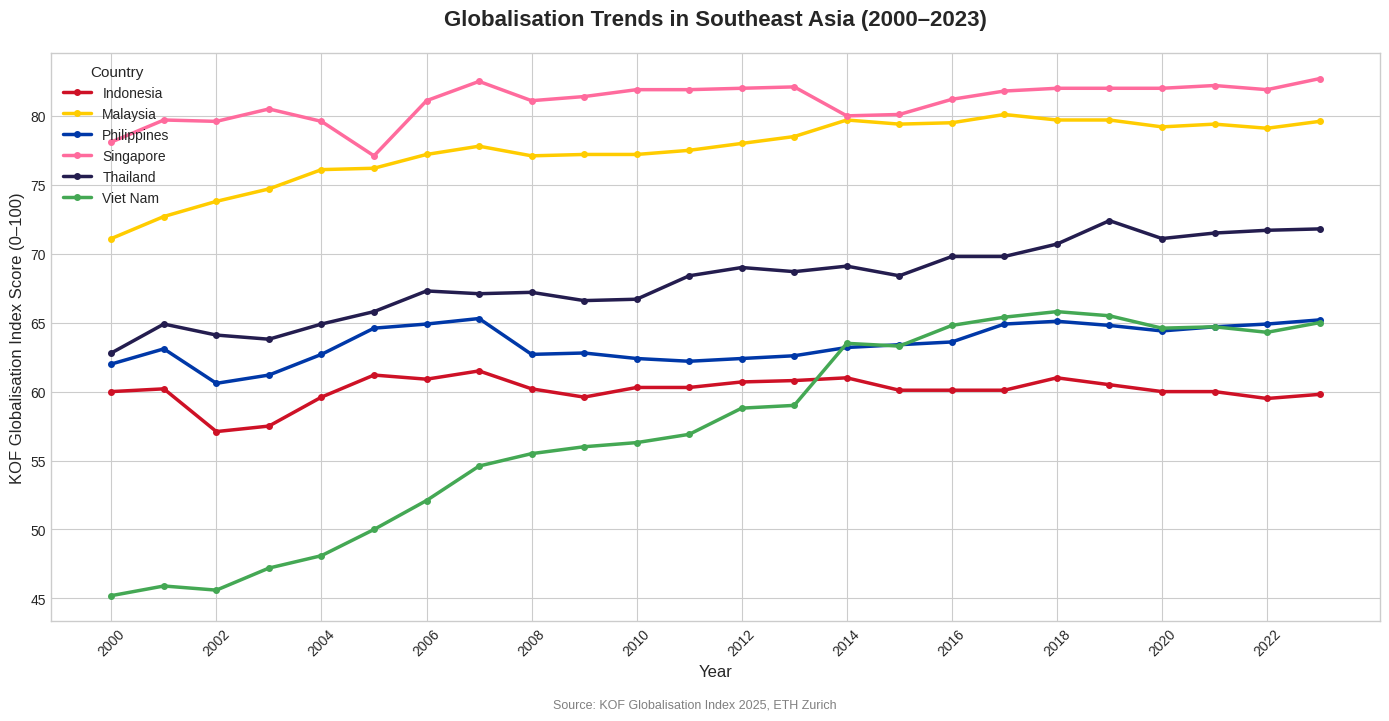

In [ ]:
# ============================================
# CHART 1 — Globalisation Trends Over Time
# Question: How did globalisation change across
# 6 SEA countries from 2000 to 2023?
# ============================================

# Set the overall style of the chart — white background, clean grid
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure — sets the canvas size (width=14, height=7 inches)
fig, ax = plt.subplots(figsize=(14, 7))

# Loop through each country and plot its KOFGI line
for country, color in country_colors.items():

    # Filter dataframe to get only rows for this country
    country_data = df[df['Country'] == country]

    # Plot a line for this country
    # x = Year, y = KOFGI score, color = flag color, linewidth = thickness
    ax.plot(country_data['Year'],
            country_data['KOFGI'],
            color=color,
            linewidth=2.5,
            marker='o',        # Small dot at each data point
            markersize=4,      # Size of the dot
            label=country)     # Label used in legend

# Add chart title and axis labels
ax.set_title('Globalisation Trends in Southeast Asia (2000–2023)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('KOF Globalisation Index Score (0–100)', fontsize=12)

# Set x-axis to show every 2 years
ax.set_xticks(range(2000, 2024, 2))

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45)

# Add legend — shows which color = which country
ax.legend(title='Country', fontsize=10, title_fontsize=11,
          loc='upper left')

# Add a note about the data source at the bottom
fig.text(0.5, -0.02, 'Source: KOF Globalisation Index 2025, ETH Zurich',
         ha='center', fontsize=9, color='gray')

# Tight layout so nothing gets cut off
plt.tight_layout()

# Save the chart as a high resolution PNG file
plt.savefig('chart1_globalisation_trends.png', dpi=300, bbox_inches='tight')

# Display the chart in Colab
plt.show()


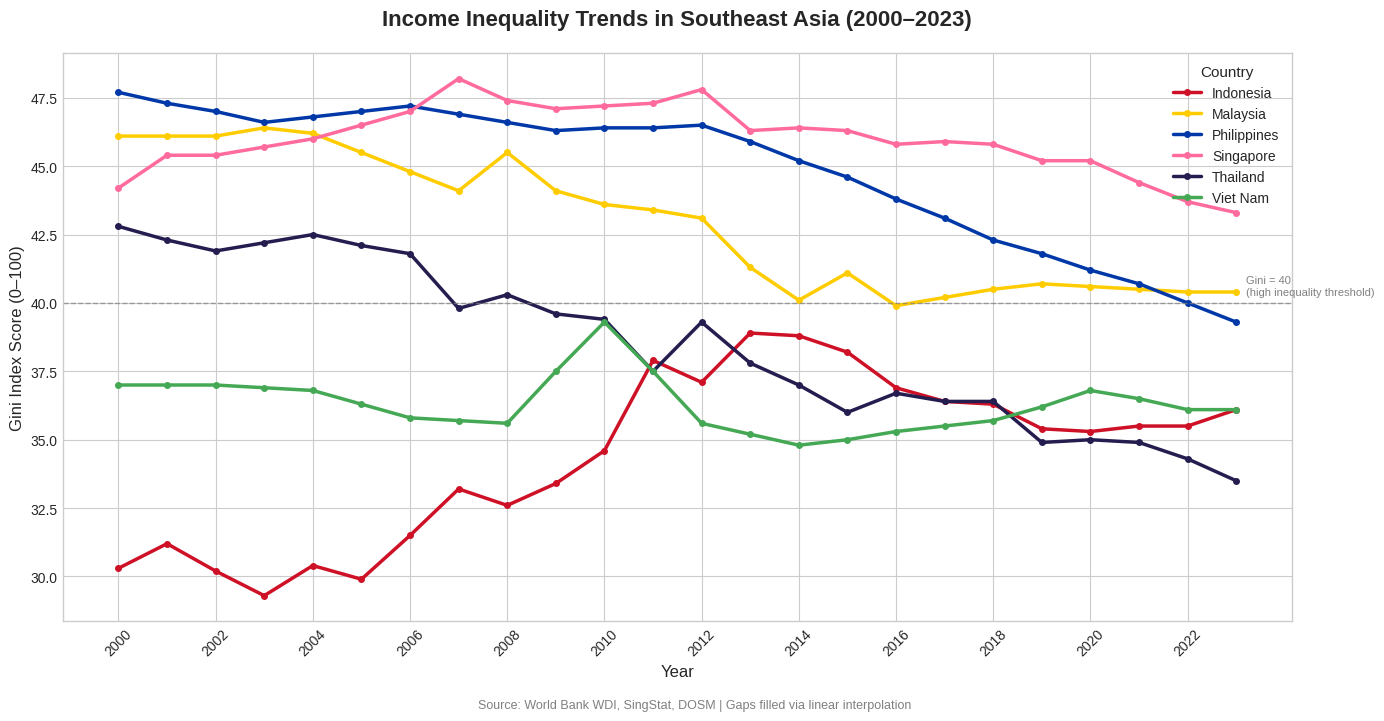

In [ ]:
# ============================================
# CHART 2 — Inequality Trends Over Time
# Question: How did income inequality change
# across 6 SEA countries from 2000 to 2023?
# ============================================

# Create the figure
fig, ax = plt.subplots(figsize=(14, 7))

# Loop through each country and plot its Gini line
for country, color in country_colors.items():

    # Filter data for this country
    country_data = df[df['Country'] == country]

    # Plot the Gini line for this country
    ax.plot(country_data['Year'],
            country_data['Gini'],
            color=color,
            linewidth=2.5,
            marker='o',       # Dot at each data point
            markersize=4,
            label=country)

# Add title and axis labels
ax.set_title('Income Inequality Trends in Southeast Asia (2000–2023)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Gini Index Score (0–100)', fontsize=12)

# Set x-axis ticks every 2 years
ax.set_xticks(range(2000, 2024, 2))
plt.xticks(rotation=45)

# Add a horizontal reference line at Gini = 40
# This is a commonly used threshold in development economics
# Above 40 = high inequality, below 40 = moderate inequality
ax.axhline(y=40, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(2023.2, 40.3, 'Gini = 40\n(high inequality threshold)',
        fontsize=8, color='gray')

# Add legend
ax.legend(title='Country', fontsize=10, title_fontsize=11,
          loc='upper right')

# Add data source note
fig.text(0.5, -0.02,
         'Source: World Bank WDI, SingStat, DOSM | Gaps filled via linear interpolation',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()

# Save as high resolution PNG
plt.savefig('chart2_gini_trends.png', dpi=300, bbox_inches='tight')

plt.show()


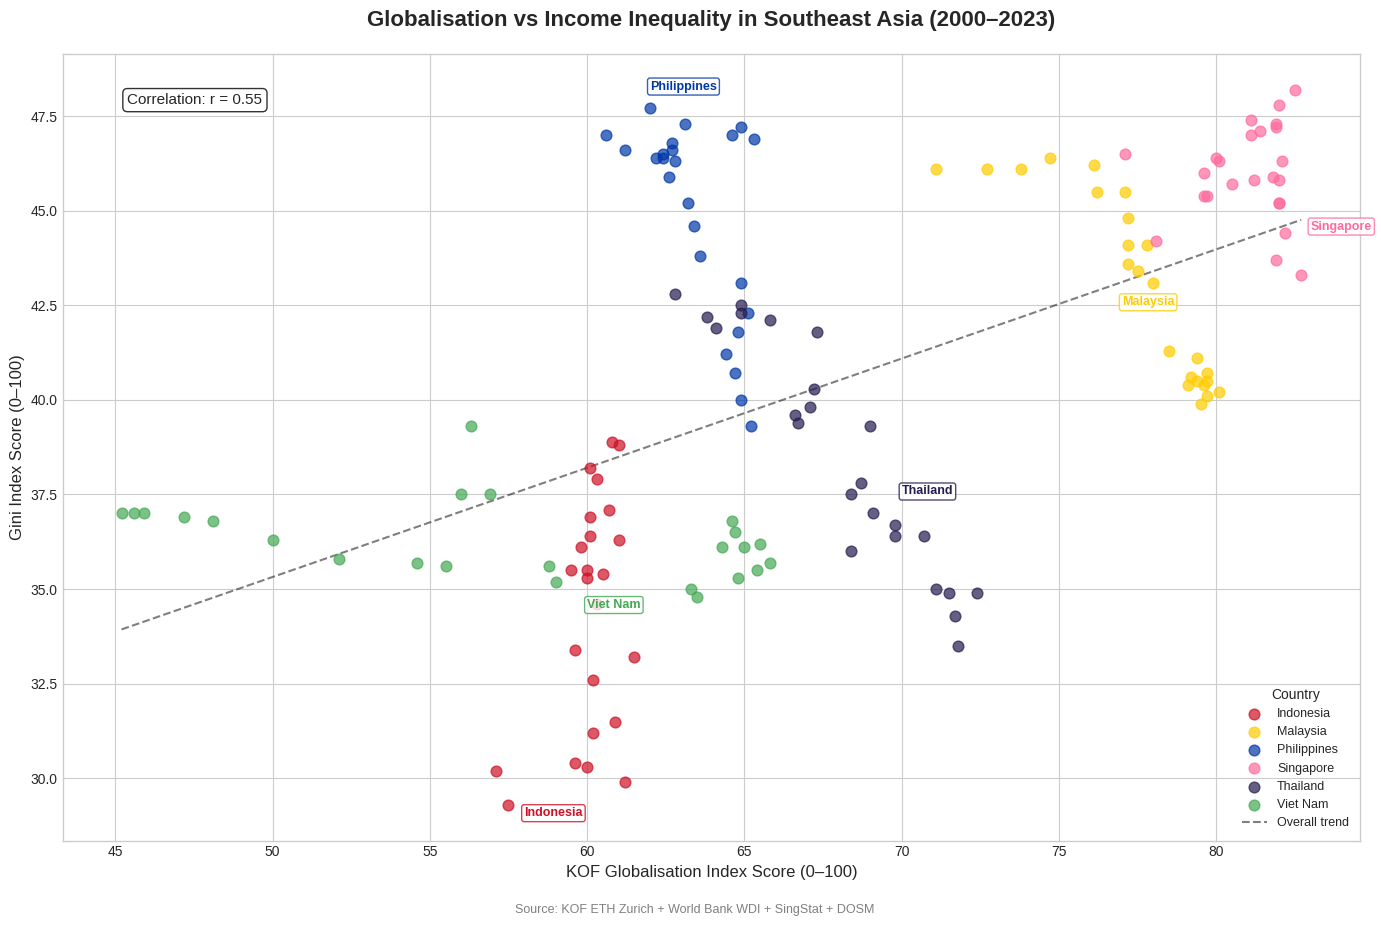

Chart 3 saved — Correlation: r = 0.55


In [ ]:
import numpy as np

# ============================================
# CHART 3 — Scatter Plot: KOFGI vs Gini
# Question: Is there a relationship between
# globalisation and income inequality?
# Each dot = one country in one year
# ============================================

fig, ax = plt.subplots(figsize=(14, 9))

# Loop through each country and plot its dots
for country, color in country_colors.items():
    country_data = df[df['Country'] == country]

    # Plot scatter dots
    ax.scatter(country_data['KOFGI'],
               country_data['Gini'],
               color=color,
               s=60,
               alpha=0.7,
               label=country,
               zorder=3)

# Add trend line
z = np.polyfit(df['KOFGI'], df['Gini'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['KOFGI'].min(), df['KOFGI'].max(), 100)
ax.plot(x_line, p(x_line),
        color='black',
        linestyle='--',
        linewidth=1.5,
        alpha=0.5,
        label='Overall trend')

# Calculate correlation
correlation = df['KOFGI'].corr(df['Gini'])
ax.text(0.05, 0.95, f'Correlation: r = {correlation:.2f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add country labels in a FIXED position away from dots
# Using average position of each country cluster instead of last point
label_positions = {
    'Indonesia':   (58, 29.0),    # Bottom left area
    'Malaysia':    (77, 42.5),    # Middle right
    'Philippines': (62, 48.2),    # Top middle
    'Singapore':   (83, 44.5),    # Far right
    'Thailand':    (70, 37.5),    # Middle
    'Viet Nam':    (60, 34.5),    # Bottom middle
}

for country, color in country_colors.items():
    x, y = label_positions[country]
    ax.annotate(country,
                xy=(x, y),
                fontsize=9,
                color=color,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2',
                         facecolor='white',
                         edgecolor=color,
                         alpha=0.8))

# Title and labels
ax.set_title('Globalisation vs Income Inequality in Southeast Asia (2000–2023)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('KOF Globalisation Index Score (0–100)', fontsize=12)
ax.set_ylabel('Gini Index Score (0–100)', fontsize=12)

# Legend — no country names since we have labels on chart
ax.legend(title='Country', fontsize=9, title_fontsize=10,
          loc='lower right')

fig.text(0.5, -0.02,
         'Source: KOF ETH Zurich + World Bank WDI + SingStat + DOSM',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('chart3_scatter_kofgi_gini.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Chart 3 saved — Correlation: r = {correlation:.2f}")

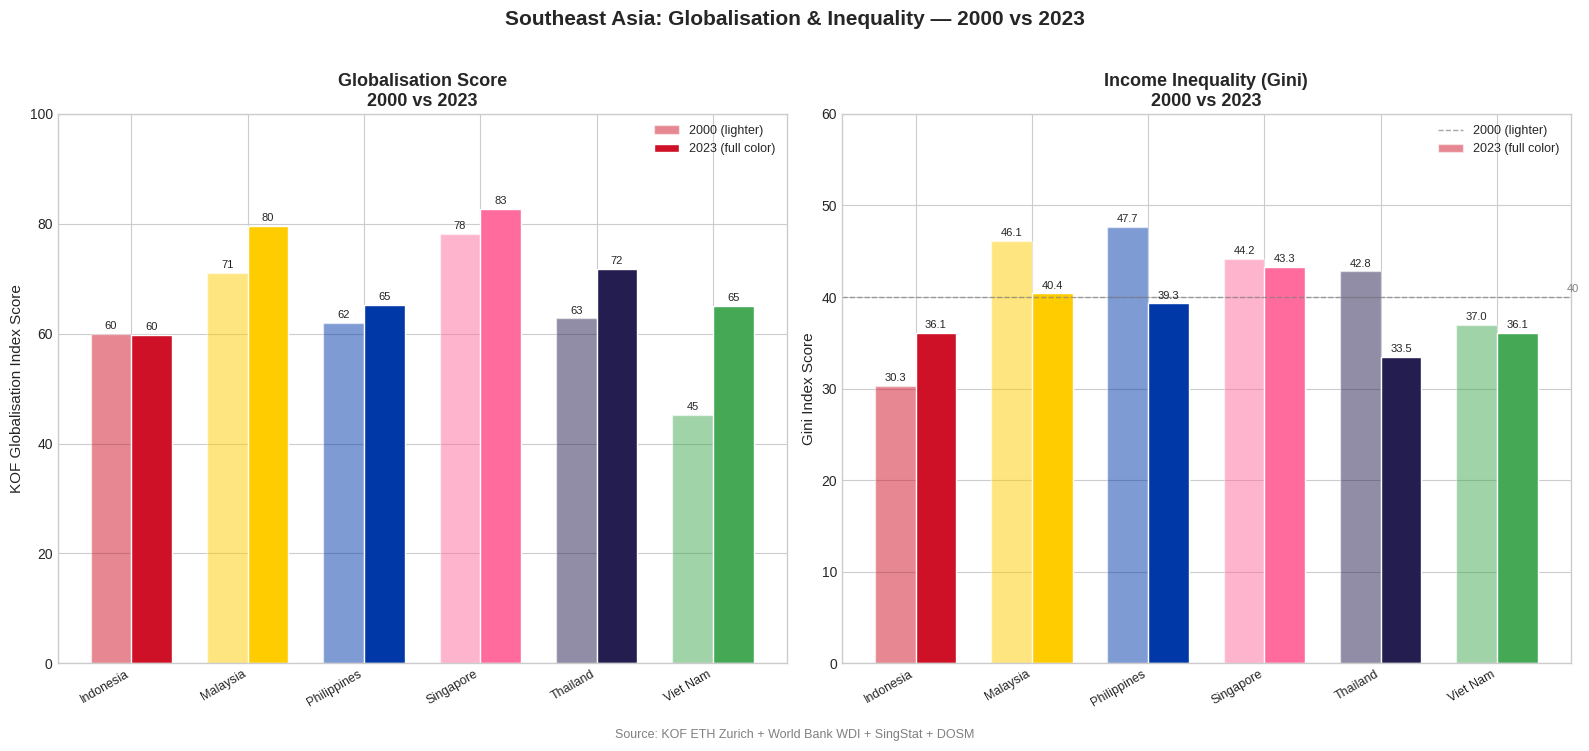

Chart 4 saved successfully


In [ ]:
# ============================================
# CHART 4 — Bar Chart: 2000 vs 2023 Comparison
# Question: How much did each country change
# in both globalisation AND inequality over
# 23 years?
# ============================================

# Get only 2000 and 2023 data rows
df_2000 = df[df['Year'] == 2000].set_index('Country')
df_2023 = df[df['Year'] == 2023].set_index('Country')

# List of countries in display order
countries = ['Indonesia', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Viet Nam']

# Get values for each country
kofgi_2000 = [df_2000.loc[c, 'KOFGI'] for c in countries]
kofgi_2023 = [df_2023.loc[c, 'KOFGI'] for c in countries]
gini_2000  = [df_2000.loc[c, 'Gini']  for c in countries]
gini_2023  = [df_2023.loc[c, 'Gini']  for c in countries]

# Set up the figure with 2 side by side charts
# Left = KOFGI comparison, Right = Gini comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Bar width and positions
bar_width = 0.35
x = np.arange(len(countries))

# ---- LEFT CHART: KOFGI 2000 vs 2023 ----
bars1 = ax1.bar(x - bar_width/2, kofgi_2000,
                bar_width,
                label='2000',
                color=[country_colors[c] for c in countries],
                alpha=0.5,      # Lighter shade = 2000
                edgecolor='white')

bars2 = ax1.bar(x + bar_width/2, kofgi_2023,
                bar_width,
                label='2023',
                color=[country_colors[c] for c in countries],
                alpha=1.0,      # Full color = 2023
                edgecolor='white')

# Add value labels on top of each bar
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{bar.get_height():.0f}',
             ha='center', va='bottom', fontsize=8)

for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{bar.get_height():.0f}',
             ha='center', va='bottom', fontsize=8)

ax1.set_title('Globalisation Score\n2000 vs 2023', fontsize=13, fontweight='bold')
ax1.set_ylabel('KOF Globalisation Index Score', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(countries, rotation=30, ha='right', fontsize=9)
ax1.legend(['2000 (lighter)', '2023 (full color)'], fontsize=9)
ax1.set_ylim(0, 100)

# ---- RIGHT CHART: GINI 2000 vs 2023 ----
bars3 = ax2.bar(x - bar_width/2, gini_2000,
                bar_width,
                label='2000',
                color=[country_colors[c] for c in countries],
                alpha=0.5,
                edgecolor='white')

bars4 = ax2.bar(x + bar_width/2, gini_2023,
                bar_width,
                label='2023',
                color=[country_colors[c] for c in countries],
                alpha=1.0,
                edgecolor='white')

# Add value labels
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom', fontsize=8)

for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom', fontsize=8)

# Add Gini = 40 threshold line on right chart
ax2.axhline(y=40, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.text(5.6, 40.5, '40', fontsize=8, color='gray')

ax2.set_title('Income Inequality (Gini)\n2000 vs 2023', fontsize=13, fontweight='bold')
ax2.set_ylabel('Gini Index Score', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(countries, rotation=30, ha='right', fontsize=9)
ax2.legend(['2000 (lighter)', '2023 (full color)'], fontsize=9)
ax2.set_ylim(0, 60)

# Overall title
fig.suptitle('Southeast Asia: Globalisation & Inequality — 2000 vs 2023',
             fontsize=15, fontweight='bold', y=1.02)

# Data source
fig.text(0.5, -0.02,
         'Source: KOF ETH Zurich + World Bank WDI + SingStat + DOSM',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('chart4_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 4 saved successfully")

In [ ]:
# ============================================
# SAVE ALL CHARTS TO GOOGLE DRIVE + GITHUB
# This downloads all chart files so you can
# push them to your GitHub repository
# ============================================

from google.colab import files

# Download all 4 charts to your computer
files.download('chart1_globalisation_trends.png')
files.download('chart2_gini_trends.png')
files.download('chart3_scatter_kofgi_gini.png')
files.download('chart4_comparison_bar.png')

print("All 4 charts downloaded successfully")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All 4 charts downloaded successfully


html nad GDP

In [34]:
# Install Plotly — the library for interactive, hoverable, web-ready charts
!pip install plotly -q

# Import Plotly modules
import plotly.express as px          # Quick high-level interactive charts
import plotly.graph_objects as go    # Fine control over chart elements
import pandas as pd

# Reload the data with GDP included
df = pd.read_excel('/content/SEA_Master_Data_FINAL_v2.xlsx')

# Confirm it loaded with all 6 columns
print(df.shape)
print(df.columns.tolist())
print(df.head())

(144, 6)
['Code', 'Country', 'Year', 'KOFGI', 'Gini', 'GDP_Growth']
  Code    Country  Year  KOFGI  Gini  GDP_Growth
0  IDN  Indonesia  2000   60.0  30.3        4.92
1  IDN  Indonesia  2001   60.2  31.2        3.64
2  IDN  Indonesia  2002   57.1  30.2        4.50
3  IDN  Indonesia  2003   57.5  29.3        4.78
4  IDN  Indonesia  2004   59.6  30.4        5.03


In [38]:
# ============================================
# INTERACTIVE CHART 1 — Globalisation Trends
# Bigger size + fixed spacing
# ============================================

country_colors = {
    'Indonesia':   '#CE1126',
    'Malaysia':    '#FFCC00',
    'Philippines': '#0038A8',
    'Singapore':   '#FF6B9D',
    'Thailand':    '#241D4F',
    'Viet Nam':    '#44A854',
}

fig = px.line(df,
              x='Year',
              y='KOFGI',
              color='Country',
              color_discrete_map=country_colors,
              markers=True,
              title='Globalisation Trends in Southeast Asia (2000–2023)',
              labels={'KOFGI': 'KOF Globalisation Index Score',
                      'Year': 'Year'})

fig.update_traces(
    hovertemplate='<b>%{fullData.name}</b><br>' +
                  'Year: %{x}<br>' +
                  'Globalisation Score: %{y:.1f}<extra></extra>',
    line=dict(width=3),
    marker=dict(size=7)
)

fig.update_layout(
    template='plotly_white',
    title_font_size=24,
    title_x=0.5,
    title_y=0.96,
    hovermode='closest',
    legend_title='Country',
    width=1300,              # Wider
    height=750,              # Taller
    font=dict(family='Arial', size=14),
    margin=dict(l=80, r=80, t=100, b=120),   # More padding around edges
    xaxis=dict(
        dtick=2,             # Show every 2 years
        tickangle=-45,       # Angle the year labels
        title_font=dict(size=16)
    ),
    yaxis=dict(
        title_font=dict(size=16)
    ),
    legend=dict(
        font=dict(size=13),
        bgcolor='rgba(255,255,255,0.8)'
    )
)

fig.add_annotation(
    text='Source: KOF Globalisation Index 2025, ETH Zurich',
    xref='paper', yref='paper',
    x=0.5, y=-0.18,
    showarrow=False,
    font=dict(size=11, color='gray')
)

fig.write_html('interactive_chart1_globalisation.html')
fig.show()


In [40]:
# ============================================
# INTERACTIVE CHART 2 — Inequality Trends
# Hover shows country, year, Gini value
# ============================================

fig = px.line(df,
              x='Year',
              y='Gini',
              color='Country',
              color_discrete_map=country_colors,
              markers=True,
              title='Income Inequality Trends in Southeast Asia (2000–2023)',
              labels={'Gini': 'Gini Index Score',
                      'Year': 'Year'})

fig.update_traces(
    hovertemplate='<b>%{fullData.name}</b><br>' +
                  'Year: %{x}<br>' +
                  'Gini Score: %{y:.1f}<extra></extra>',
    line=dict(width=3),
    marker=dict(size=7)
)

fig.update_layout(
    template='plotly_white',
    title_font_size=24,
    title_x=0.5,
    title_y=0.96,
    hovermode='closest',
    legend_title='Country',
    width=1300,
    height=750,
    font=dict(family='Arial', size=14),
    margin=dict(l=80, r=80, t=100, b=120),
    xaxis=dict(dtick=2, tickangle=-45, title_font=dict(size=16)),
    yaxis=dict(title_font=dict(size=16)),
    legend=dict(font=dict(size=13), bgcolor='rgba(255,255,255,0.8)')
)

# Add the Gini = 40 high inequality threshold line
fig.add_hline(y=40,
              line_dash='dash',
              line_color='gray',
              annotation_text='Gini = 40 (high inequality threshold)',
              annotation_position='top right')

fig.add_annotation(
    text='Source: World Bank WDI, SingStat, DOSM | Gaps filled via linear interpolation',
    xref='paper', yref='paper',
    x=0.5, y=-0.18,
    showarrow=False,
    font=dict(size=11, color='gray')
)

fig.write_html('interactive_chart2_inequality.html')
fig.show()
